Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  

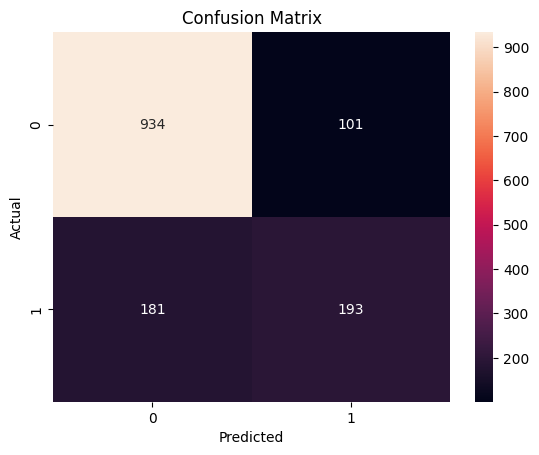

Pipeline Saved!
[0 1 0 0 0]


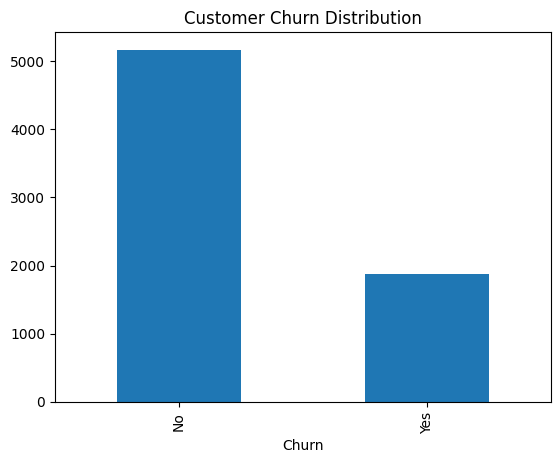

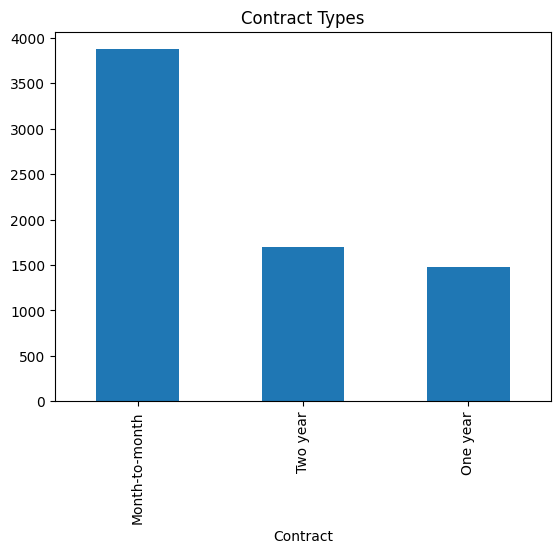

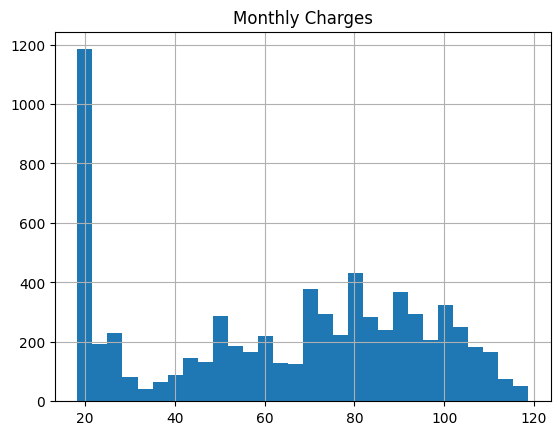

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import joblib
from google.colab import files
files.upload()

df = pd.read_csv("Telco-Customer-Churn.csv")

print(df.head())
print(df.shape)

df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No":0,
    "Yes":1
})

num_cols = X.select_dtypes(
    include=["int64","float64"]
).columns

cat_cols = X.select_dtypes(
    include=["object"]
).columns
print(num_cols)
print(cat_cols)
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_pipeline.fit(X_train, y_train)
y_pred = log_pipeline.predict(X_test)
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(
      y_test,
      y_pred))

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print(classification_report(
      y_test,
      rf_pred))

param_grid = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[10,20,None],
    "classifier__min_samples_split":[2,5]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)

print("Best Score:")
print(grid_search.best_score_)
best_model = grid_search.best_estimator_

preds = best_model.predict(X_test)

print("Final Accuracy:",
      accuracy_score(y_test, preds))

print(classification_report(
      y_test,
      preds))
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, preds)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
joblib.dump(
    best_model,
    "saved_pipeline.pkl"
)

print("Pipeline Saved!")
loaded_model = joblib.load(
    "saved_pipeline.pkl"
)

prediction = loaded_model.predict(
    X_test.iloc[:5]
)

print(prediction)
df["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.show()
df["Contract"].value_counts().plot(
    kind="bar"
)

plt.title("Contract Types")
plt.show()
df["MonthlyCharges"].hist(
    bins=30
)

plt.title("Monthly Charges")
plt.show()